# INSY 5378 - Anchors and Counterfactuals

## Loan Approval Explainability

**Keishana Morsley**

## The Preparations

### Loading the Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

SEED = 42
np.random.seed(SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


### Understanding and Preparing the Data

In [ ]:
from pathlib import Path

file_path = Path("loan_dataset.xlsx")

if not file_path.exists():
    try:
        from google.colab import files
        print("Please upload loan_dataset.xlsx.")
        files.upload()
    except ImportError:
        pass

loan_df = pd.read_excel("loan_dataset.xlsx", sheet_name="Loan_Dataset")
loan_df.head()

,Applicant_ID,Age,Gender,Race,Annual_Income,Credit_Score,Loan_Amount_Requested,Debt_To_Income_Ratio,Employment_Length_Years,Savings_Balance,Loan_Approved
0,APP-00001,71,Female,White,71993,817,42001,0.44,2,20462,1
1,APP-00002,57,Male,Asian,75403,790,13007,0.46,13,26970,1
2,APP-00003,28,Male,Black,76444,631,40096,0.45,4,6499,1
3,APP-00004,27,Male,Black,57108,684,46787,0.26,4,974,0
4,APP-00005,34,Male,White,114106,658,14255,0.15,4,14615,1


In [ ]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Applicant_ID             1500 non-null   object 
 1   Age                      1500 non-null   int64  
 2   Gender                   1500 non-null   object 
 3   Race                     1500 non-null   object 
 4   Annual_Income            1500 non-null   int64  
 5   Credit_Score             1500 non-null   int64  
 6   Loan_Amount_Requested    1500 non-null   int64  
 7   Debt_To_Income_Ratio     1500 non-null   float64
 8   Employment_Length_Years  1500 non-null   int64  
 9   Savings_Balance          1500 non-null   int64  
 10  Loan_Approved            1500 non-null   int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 129.0+ KB


### Data Preparation

In [ ]:
# Remove Applicant_ID because it is a unique identifier and not a predictive feature
loan_df = loan_df.drop(columns=["Applicant_ID"])

loan_df.head()

,Age,Gender,Race,Annual_Income,Credit_Score,Loan_Amount_Requested,Debt_To_Income_Ratio,Employment_Length_Years,Savings_Balance,Loan_Approved
0,71,Female,White,71993,817,42001,0.44,2,20462,1
1,57,Male,Asian,75403,790,13007,0.46,13,26970,1
2,28,Male,Black,76444,631,40096,0.45,4,6499,1
3,27,Male,Black,57108,684,46787,0.26,4,974,0
4,34,Male,White,114106,658,14255,0.15,4,14615,1


In [ ]:
continuous_features = [
    'Age',
    'Annual_Income',
    'Credit_Score',
    'Loan_Amount_Requested',
    'Debt_To_Income_Ratio',
    'Employment_Length_Years',
    'Savings_Balance'
]

categorical_features = [
    'Gender',
    'Race'
]

target_col = 'Loan_Approved'
features = continuous_features + categorical_features

X = loan_df[features].copy()
y = loan_df[target_col]

for col in categorical_features:
    X[col] = X[col].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print(f"Dataset summary: {X_train.shape[0]} training instances, {X_test.shape[0]} test instances.")
print(f"Continuous features: {continuous_features}")
print(f"Categorical features: {categorical_features}")

X_train.head()

Dataset summary: 1200 training instances, 300 test instances.
Continuous features: ['Age', 'Annual_Income', 'Credit_Score', 'Loan_Amount_Requested', 'Debt_To_Income_Ratio', 'Employment_Length_Years', 'Savings_Balance']
Categorical features: ['Gender', 'Race']


,Age,Annual_Income,Credit_Score,Loan_Amount_Requested,Debt_To_Income_Ratio,Employment_Length_Years,Savings_Balance,Gender,Race
1308,34,69179,708,27829,0.54,5,25833,Male,White
61,26,102647,762,23402,0.49,9,53094,Male,White
959,45,34906,695,28052,0.16,7,20018,Male,Black
341,37,61806,527,5493,0.30,5,1501,Male,White
675,45,86268,691,41486,0.52,7,67211,Female,Asian


## Machine Learning Model

### Preprocessing Pipeline and Model Training

In [ ]:
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', continuous_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=120, max_depth=6, random_state=SEED))
])

pipeline.fit(X_train, y_train)

acc = pipeline.score(X_test, y_test)
print(f"Model Test Accuracy: {acc:.2%}")

Model Test Accuracy: 66.33%


## Selecting Instances for Explanation

In [ ]:
# Find one correctly predicted Approved instance (1)
preds = pipeline.predict(X_test)
probs = pipeline.predict_proba(X_test)

approved_indices = np.where((preds == 1) & (y_test.values == 1))[0]
approved_idx = approved_indices[0]

approved_instance = X_test.iloc[approved_idx:approved_idx+1]

print(f"Selected Approved Instance Index: {approved_idx}")
print(f"Model Prediction: {pipeline.predict(approved_instance)[0]} (0 = Denied, 1 = Approved)")
print(f"Predicted Probabilities [Denied, Approved]: {pipeline.predict_proba(approved_instance)[0]}")

display(approved_instance)

Selected Approved Instance Index: 1
Model Prediction: 1 (0 = Denied, 1 = Approved)
Predicted Probabilities [Denied, Approved]: [0.43327484 0.56672516]


,Age,Annual_Income,Credit_Score,Loan_Amount_Requested,Debt_To_Income_Ratio,Employment_Length_Years,Savings_Balance,Gender,Race
140,65,78077,646,9578,0.29,8,26264,Female,Asian


In [ ]:
# Find two correctly predicted Denied instances (0)
denied_indices = np.where((preds == 0) & (y_test.values == 0))[0]

denied_idx_1 = denied_indices[0]
denied_idx_2 = denied_indices[1]

denied_instance_1 = X_test.iloc[denied_idx_1:denied_idx_1+1]
denied_instance_2 = X_test.iloc[denied_idx_2:denied_idx_2+1]

print(f"Selected Denied Instance 1 Index: {denied_idx_1}")
print(f"Model Prediction: {pipeline.predict(denied_instance_1)[0]} (0 = Denied, 1 = Approved)")
print(f"Predicted Probabilities [Denied, Approved]: {pipeline.predict_proba(denied_instance_1)[0]}")
display(denied_instance_1)

print(f"Selected Denied Instance 2 Index: {denied_idx_2}")
print(f"Model Prediction: {pipeline.predict(denied_instance_2)[0]} (0 = Denied, 1 = Approved)")
print(f"Predicted Probabilities [Denied, Approved]: {pipeline.predict_proba(denied_instance_2)[0]}")
display(denied_instance_2)

Selected Denied Instance 1 Index: 0
Model Prediction: 0 (0 = Denied, 1 = Approved)
Predicted Probabilities [Denied, Approved]: [0.50178094 0.49821906]


,Age,Annual_Income,Credit_Score,Loan_Amount_Requested,Debt_To_Income_Ratio,Employment_Length_Years,Savings_Balance,Gender,Race
10,38,57500,650,39188,0.17,8,10774,Female,White


Selected Denied Instance 2 Index: 3
Model Prediction: 0 (0 = Denied, 1 = Approved)
Predicted Probabilities [Denied, Approved]: [0.56211135 0.43788865]


,Age,Annual_Income,Credit_Score,Loan_Amount_Requested,Debt_To_Income_Ratio,Employment_Length_Years,Savings_Balance,Gender,Race
376,63,48988,719,24194,0.35,1,6317,Female,Hispanic


## Method 1: Anchors (`alibi`)

Anchors search for sufficient conditions such that, when those conditions are present, the model prediction remains unchanged with high precision.

In [ ]:
# Install Alibi only if it is not already available.
# Use --no-deps so Colab does not replace its working NumPy environment.
try:
    from alibi.explainers import AnchorTabular
except (ModuleNotFoundError, ImportError):
    %pip install -q --no-deps alibi==0.9.6

    # Alibi 0.9.6 imports a TensorFlow masked-language-model class that is
    # not exposed by some newer Transformers builds. AnchorTabular does not
    # use that text-model class, so provide a compatibility alias before
    # importing Alibi.
    import transformers

    if not hasattr(transformers, "TFAutoModelForMaskedLM"):
        class TFAutoModelForMaskedLM:
            pass

        transformers.TFAutoModelForMaskedLM = TFAutoModelForMaskedLM

    from alibi.explainers import AnchorTabular

print("Using alibi AnchorTabular.")

# 1. Build category mapping dictionaries for AnchorTabular
# Alibi encodes categorical variables as integers (0, 1, 2...) internally
category_map = {}

for col in categorical_features:
    col_idx = features.index(col)
    category_map[col_idx] = list(X_train[col].unique())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.1/522.1 kB 12.5 MB/s eta 0:00:00
Using alibi AnchorTabular.


In [ ]:
# 2. Prediction wrapper: maps integer-encoded categorical columns back to strings
def predict_fn_alibi(x):
    df_pred = pd.DataFrame(x, columns=features)

    for col_idx, col_name in enumerate(features):
        if col_idx in category_map:
            cats = category_map[col_idx]
            df_pred[col_name] = df_pred[col_name].apply(
                lambda val: cats[int(val)] if 0 <= int(val) < len(cats) else cats[0]
            )
        else:
            df_pred[col_name] = pd.to_numeric(df_pred[col_name])

    return pipeline.predict(df_pred)

In [ ]:
# 3. Encode the training set and selected instances with integer codes for Alibi
X_train_anchor = X_train.copy()

approved_instance_anchor = approved_instance.copy()
denied_instance_1_anchor = denied_instance_1.copy()

for col_idx, col_name in enumerate(features):
    if col_idx in category_map:
        cat_list = category_map[col_idx]
        mapping = {name: i for i, name in enumerate(cat_list)}

        X_train_anchor[col_name] = X_train_anchor[col_name].map(mapping).fillna(0).astype(int)
        approved_instance_anchor[col_name] = approved_instance_anchor[col_name].map(mapping).fillna(0).astype(int)
        denied_instance_1_anchor[col_name] = denied_instance_1_anchor[col_name].map(mapping).fillna(0).astype(int)

In [ ]:
# 4. Initialize AnchorTabular
explainer_anchor = AnchorTabular(
    predictor=predict_fn_alibi,
    feature_names=features,
    categorical_names=category_map
)

# 5. Fit explainer
explainer_anchor.fit(X_train_anchor.values)

AnchorTabular(meta={
  'name': 'AnchorTabular',
  'type': ['blackbox'],
  'explanations': ['local'],
  'params': {'seed': None, 'disc_perc': (25, 50, 75)},
  'version': '0.9.6'}
)

### Anchor Explanation - Approved Instance

In [ ]:
# 6. Explain the Approved instance
anchor_exp_approved = explainer_anchor.explain(
    approved_instance_anchor.values[0],
    threshold=0.95
)

print("=== ANCHOR EXPLANATION: APPROVED INSTANCE ===")
print(f"Anchor Rule for Prediction '{anchor_exp_approved.raw['prediction']}':")

for rule in anchor_exp_approved.anchor:
    print(f"  • {rule}")

print(f"Precision: {anchor_exp_approved.precision:.2%}")
print(f"Coverage:  {anchor_exp_approved.coverage:.2%}")

=== ANCHOR EXPLANATION: APPROVED INSTANCE ===
Anchor Rule for Prediction '[1]':
  • Credit_Score > 626.75
  • Race = Asian
  • Annual_Income > 74669.00
  • Employment_Length_Years > 7.00
Precision: 99.36%
Coverage:  1.66%


### Anchor Explanation - Denied Instance

In [ ]:
# 7. Explain the Denied instance
anchor_exp_denied = explainer_anchor.explain(
    denied_instance_1_anchor.values[0],
    threshold=0.95
)

print("=== ANCHOR EXPLANATION: DENIED INSTANCE ===")
print(f"Anchor Rule for Prediction '{anchor_exp_denied.raw['prediction']}':")

for rule in anchor_exp_denied.anchor:
    print(f"  • {rule}")

print(f"Precision: {anchor_exp_denied.precision:.2%}")
print(f"Coverage:  {anchor_exp_denied.coverage:.2%}")

=== ANCHOR EXPLANATION: DENIED INSTANCE ===
Anchor Rule for Prediction '[0]':
  • Credit_Score <= 680.00
  • Annual_Income <= 58123.75
  • Gender = Female
  • 33.00 < Age <= 45.00
  • Employment_Length_Years <= 11.00
  • Savings_Balance <= 21189.75
Precision: 96.02%
Coverage:  1.19%


## Method 2: Counterfactual Explanations with DiCE (`dice-ml`)

Counterfactuals answer: **What minimal, plausible changes would flip a decision from Denied to Approved?**

Because Age, Gender, and Race are protected or non-actionable characteristics, they are held fixed. The financial and employment variables are allowed to vary.

In [ ]:
try:
    import dice_ml
except ModuleNotFoundError:
    %pip install -q dice-ml
    import dice_ml

# Prepare dataset with outcome column for DiCE
train_dataset = pd.concat([X_train, y_train], axis=1)

d = dice_ml.Data(
    dataframe=train_dataset,
    continuous_features=continuous_features,
    outcome_name=target_col
)

# DiCE wraps the trained scikit-learn pipeline
m = dice_ml.Model(model=pipeline, backend="sklearn")

# Initialize DiCE explainer
exp_dice = dice_ml.Dice(d, m, method="random")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 45.5 MB/s eta 0:00:00


### Counterfactual Explanation - Denied Instance 1

In [ ]:
# Actionable features only
actionable_features = [
    'Annual_Income',
    'Credit_Score',
    'Loan_Amount_Requested',
    'Debt_To_Income_Ratio',
    'Employment_Length_Years',
    'Savings_Balance'
]

cf_denied_1 = exp_dice.generate_counterfactuals(
    denied_instance_1,
    total_CFs=3,
    desired_class=1,
    features_to_vary=actionable_features
)

print("=== COUNTERFACTUAL EXPLANATIONS: DENIED INSTANCE 1 ===")
cf_denied_1.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  4.32it/s]

=== COUNTERFACTUAL EXPLANATIONS: DENIED INSTANCE 1 ===
Query instance (original outcome : 0)


,Age,Annual_Income,Credit_Score,Loan_Amount_Requested,Debt_To_Income_Ratio,Employment_Length_Years,Savings_Balance,Gender,Race,Loan_Approved
0,38,57500,650,39188,0.17,8,10774,Female,White,0



Diverse Counterfactual set (new outcome: 1)


,Age,Annual_Income,Credit_Score,Loan_Amount_Requested,Debt_To_Income_Ratio,Employment_Length_Years,Savings_Balance,Gender,Race,Loan_Approved
0,-,-,-,-,-,-,-,-,-,1
1,-,-,-,-,-,-,-,-,-,1
2,-,-,770,-,-,-,-,-,-,1


### Counterfactual Explanation - Denied Instance 2

In [ ]:
cf_denied_2 = exp_dice.generate_counterfactuals(
    denied_instance_2,
    total_CFs=3,
    desired_class=1,
    features_to_vary=actionable_features
)

print("=== COUNTERFACTUAL EXPLANATIONS: DENIED INSTANCE 2 ===")
cf_denied_2.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [01:16<00:00, 76.18s/it]

=== COUNTERFACTUAL EXPLANATIONS: DENIED INSTANCE 2 ===
Query instance (original outcome : 0)


,Age,Annual_Income,Credit_Score,Loan_Amount_Requested,Debt_To_Income_Ratio,Employment_Length_Years,Savings_Balance,Gender,Race,Loan_Approved
0,63,48988,719,24194,0.35,1,6317,Female,Hispanic,0



Diverse Counterfactual set (new outcome: 1)


,Age,Annual_Income,Credit_Score,Loan_Amount_Requested,Debt_To_Income_Ratio,Employment_Length_Years,Savings_Balance,Gender,Race,Loan_Approved
0,-,-,-,-,-,-,-,-,-,1
1,-,-,786,-,-,-,-,-,-,1
2,-,-,828,-,-,-,-,-,-,1


## Comparative Method: LIME (Local Interpretable Model-agnostic Explanations)

LIME perturbs the input locally, sends the perturbed observations through the black-box model, and fits a sparse local linear model.

In [ ]:
try:
    import lime
    import lime.lime_tabular
except ModuleNotFoundError:
    %pip install -q lime
    import lime
    import lime.lime_tabular

import numpy as np
import pandas as pd

# 1. Build integer-encoded training and selected data for LIME
categorical_indices = [features.index(col) for col in categorical_features]
categorical_names = {}

X_train_lime = X_train.copy()
approved_lime = approved_instance.copy()
denied_lime = denied_instance_1.copy()

for idx, col in zip(categorical_indices, categorical_features):
    categories = list(X_train[col].unique())
    categorical_names[idx] = categories
    mapping = {cat: i for i, cat in enumerate(categories)}

    X_train_lime[col] = X_train_lime[col].map(mapping).fillna(0).astype(int)
    approved_lime[col] = approved_lime[col].map(mapping).fillna(0).astype(int)
    denied_lime[col] = denied_lime[col].map(mapping).fillna(0).astype(int)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 12.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# 2. Prediction wrapper: Converts integer codes back to strings for the pipeline
def predict_fn_lime(numpy_array):
    df_temp = pd.DataFrame(numpy_array, columns=features)

    for idx, col in zip(categorical_indices, categorical_features):
        cats = categorical_names[idx]
        df_temp[col] = df_temp[col].apply(
            lambda v: cats[int(v)] if 0 <= int(v) < len(cats) else cats[0]
        )

    for col in continuous_features:
        df_temp[col] = pd.to_numeric(df_temp[col])

    return pipeline.predict_proba(df_temp)

In [ ]:
# 3. Initialize LimeTabularExplainer
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_lime.values.astype(float),
    feature_names=features,
    class_names=['Denied', 'Approved'],
    categorical_features=categorical_indices,
    categorical_names=categorical_names,
    mode='classification',
    random_state=SEED
)

### LIME Explanation - Approved Instance

=== LIME LOCAL FEATURE ATTRIBUTIONS: APPROVED INSTANCE ===
  • 626.75 < Credit_Score <= 680.00               : -0.0507 (Pushes to Denied)
  • 74669.00 < Annual_Income <= 91435.25          : +0.0453 (Supports Approved)
  • Race=Asian                                    : +0.0406 (Supports Approved)
  • Gender=Female                                 : -0.0345 (Pushes to Denied)
  • Age > 59.00                                   : +0.0307 (Supports Approved)
  • Loan_Amount_Requested <= 15854.50             : -0.0272 (Pushes to Denied)
  • 7.00 < Employment_Length_Years <= 11.00       : +0.0104 (Supports Approved)


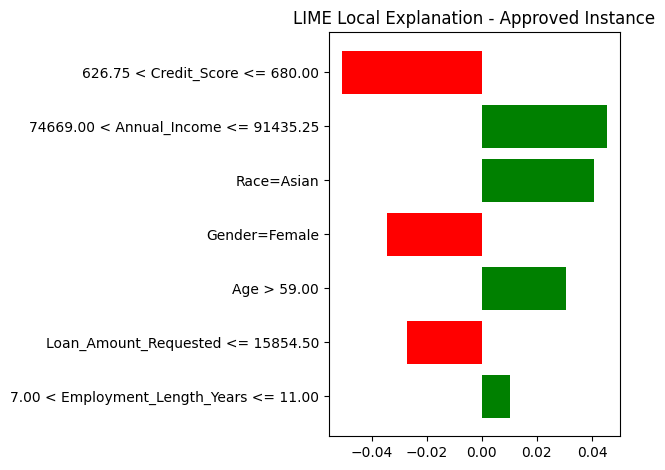

In [ ]:
# 4. Generate local explanation for the Approved instance
exp_lime_approved = explainer_lime.explain_instance(
    data_row=approved_lime.values[0].astype(float),
    predict_fn=predict_fn_lime,
    num_features=7
)

print("=== LIME LOCAL FEATURE ATTRIBUTIONS: APPROVED INSTANCE ===")

for feature_rule, weight in exp_lime_approved.as_list():
    direction = "Supports Approved" if weight > 0 else "Pushes to Denied"
    print(f"  • {feature_rule:<45} : {weight:+.4f} ({direction})")

fig = exp_lime_approved.as_pyplot_figure()
plt.title("LIME Local Explanation - Approved Instance")
plt.tight_layout()
plt.show()

### LIME Explanation - Denied Instance

=== LIME LOCAL FEATURE ATTRIBUTIONS: DENIED INSTANCE ===
  • Race=White                                    : +0.1427 (Supports Approved)
  • Annual_Income <= 58123.75                     : -0.1086 (Pushes to Denied)
  • 626.75 < Credit_Score <= 680.00               : -0.0424 (Pushes to Denied)
  • Gender=Female                                 : -0.0364 (Pushes to Denied)
  • Debt_To_Income_Ratio <= 0.23                  : +0.0244 (Supports Approved)
  • 7.00 < Employment_Length_Years <= 11.00       : +0.0161 (Supports Approved)
  • 33.00 < Age <= 45.00                          : -0.0102 (Pushes to Denied)


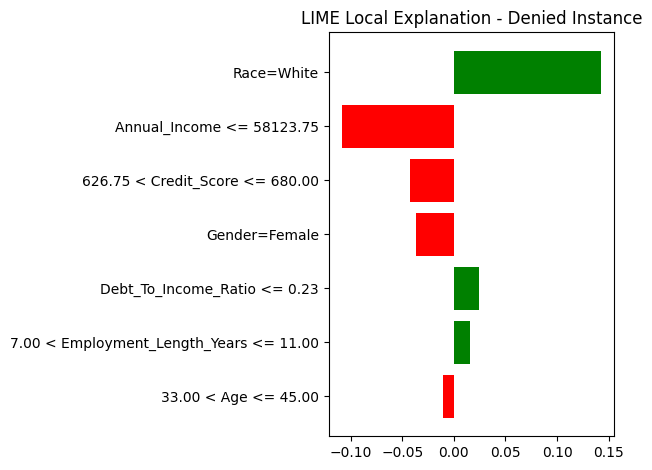

In [ ]:
# 5. Generate local explanation for the Denied instance
exp_lime_denied = explainer_lime.explain_instance(
    data_row=denied_lime.values[0].astype(float),
    predict_fn=predict_fn_lime,
    num_features=7
)

print("=== LIME LOCAL FEATURE ATTRIBUTIONS: DENIED INSTANCE ===")

for feature_rule, weight in exp_lime_denied.as_list():
    direction = "Supports Approved" if weight > 0 else "Pushes to Denied"
    print(f"  • {feature_rule:<45} : {weight:+.4f} ({direction})")

fig = exp_lime_denied.as_pyplot_figure()
plt.title("LIME Local Explanation - Denied Instance")
plt.tight_layout()
plt.show()

## Comparative Method: KernelSHAP (Shapley Additive Explanations)

SHAP calculates the marginal contribution of each feature across possible feature subsets. The same Approved and Denied instances used for Anchors and LIME are explained below.

In [ ]:
try:
    import shap
except ModuleNotFoundError:
    %pip install -q shap
    import shap

# Transform training data to feed into the underlying model
preprocessor_fitted = pipeline.named_steps['preprocessor']
classifier = pipeline.named_steps['classifier']

X_train_trans = preprocessor_fitted.transform(X_train)
approved_trans = preprocessor_fitted.transform(approved_instance)
denied_trans = preprocessor_fitted.transform(denied_instance_1)

transformed_feature_names = preprocessor_fitted.get_feature_names_out()

# Background summary for KernelSHAP to balance runtime
background = shap.kmeans(X_train_trans, 20)

explainer_shap = shap.KernelExplainer(
    classifier.predict_proba,
    background
)

### SHAP Explanation - Approved Instance

  0%|          | 0/1 [00:00<?, ?it/s]

=== SHAP VALUES (CLASS 1: APPROVED) ===
  • cat__Race_White                               : -0.0786
  • num__Credit_Score                             : -0.0504
  • num__Age                                      : +0.0457
  • cat__Race_Asian                               : +0.0358
  • num__Annual_Income                            : +0.0357
  • num__Loan_Amount_Requested                    : -0.0222
  • num__Employment_Length_Years                  : +0.0064


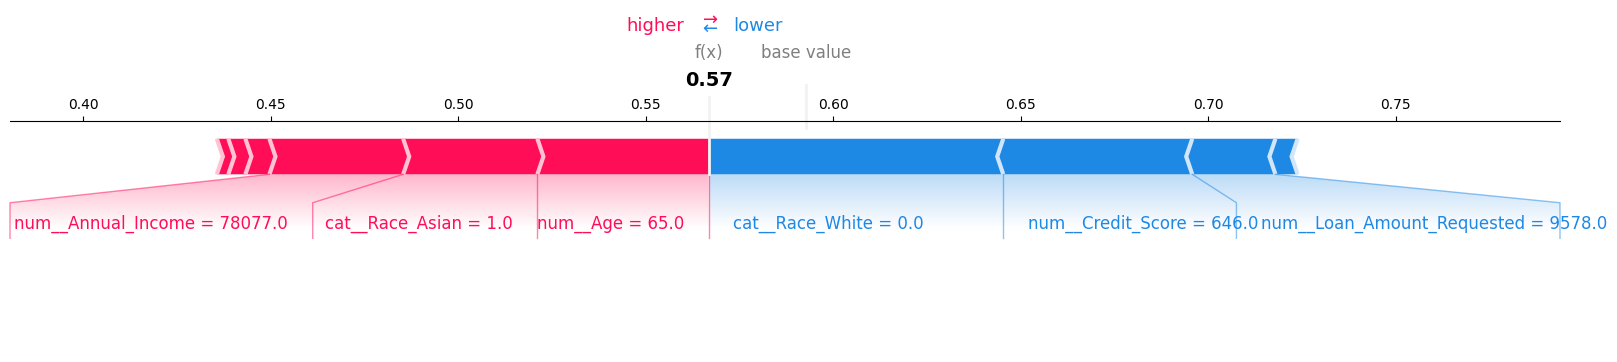

In [ ]:
shap_values_approved = explainer_shap.shap_values(
    approved_trans,
    nsamples=100
)

# Class 1 = Approved
shap_approved = (
    shap_values_approved[1][0]
    if isinstance(shap_values_approved, list)
    else shap_values_approved[:, :, 1][0]
)

print("=== SHAP VALUES (CLASS 1: APPROVED) ===")

top_indices = np.argsort(np.abs(shap_approved))[::-1][:7]

for idx in top_indices:
    feat = transformed_feature_names[idx]
    val = shap_approved[idx]
    print(f"  • {feat:<45} : {val:+.4f}")

shap.force_plot(
    explainer_shap.expected_value[1],
    shap_approved,
    approved_trans[0],
    feature_names=transformed_feature_names,
    matplotlib=True,
    show=True
)

### SHAP Explanation - Denied Instance

  0%|          | 0/1 [00:00<?, ?it/s]

=== SHAP VALUES (CLASS 0: DENIED) ===
  • num__Annual_Income                            : +0.0855
  • num__Credit_Score                             : +0.0311
  • cat__Race_White                               : -0.0269
  • num__Age                                      : +0.0116
  • num__Debt_To_Income_Ratio                     : -0.0108
  • cat__Gender_Female                            : +0.0097
  • num__Loan_Amount_Requested                    : -0.0061


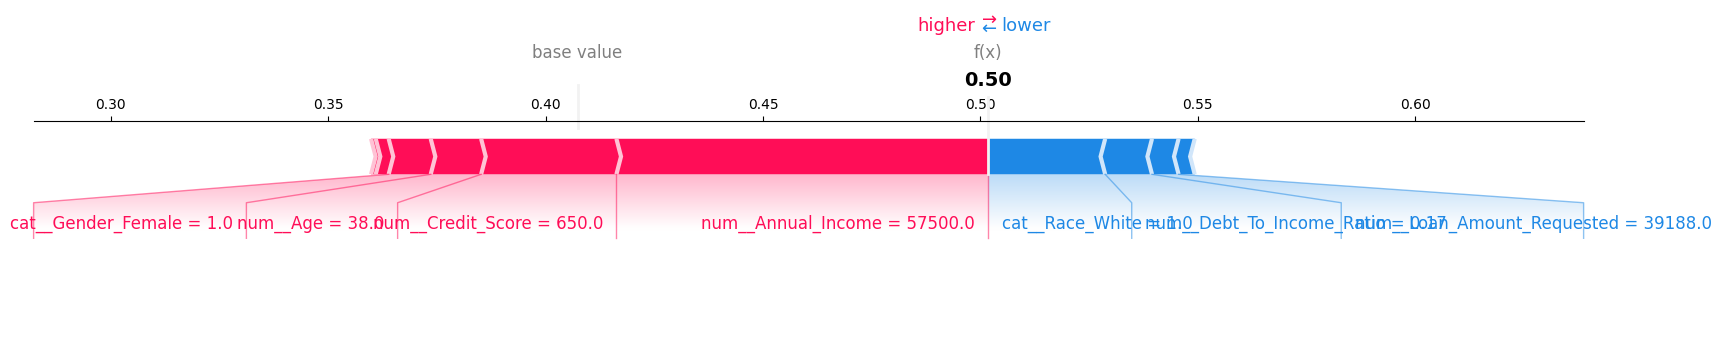

In [ ]:
shap_values_denied = explainer_shap.shap_values(
    denied_trans,
    nsamples=100
)

# Class 0 = Denied
shap_denied = (
    shap_values_denied[0][0]
    if isinstance(shap_values_denied, list)
    else shap_values_denied[:, :, 0][0]
)

print("=== SHAP VALUES (CLASS 0: DENIED) ===")

top_indices = np.argsort(np.abs(shap_denied))[::-1][:7]

for idx in top_indices:
    feat = transformed_feature_names[idx]
    val = shap_denied[idx]
    print(f"  • {feat:<45} : {val:+.4f}")

shap.force_plot(
    explainer_shap.expected_value[0],
    shap_denied,
    denied_trans[0],
    feature_names=transformed_feature_names,
    matplotlib=True,
    show=True
)

## Conclusion

This assignment used a Random Forest classifier to predict loan approval and applied Anchors, Counterfactual Explanations, LIME, and SHAP to explain individual predictions.

Anchors were created for one Approved applicant and one Denied applicant. LIME and SHAP were then used on those same two instances to show the local feature contributions associated with each prediction. Finally, counterfactual explanations were created for two Denied applicants to identify changes that could produce an Approved prediction.

Because the data dictionary identifies Age, Gender, and Race as protected or non-actionable characteristics, those variables were not allowed to change in the counterfactual explanations. The counterfactual analysis instead focused on financial and employment variables.